In [5]:
import os
print(os.getcwd())

C:\Users\Shiva\Downloads\bluestock\Advanced_Analytics


In [2]:
import os
# Check what is in the folder above the current one
print("Files/Folders above current:", os.listdir('..'))

Files/Folders above current: ['.git', '.ipynb_checkpoints', 'Advanced_Analytics', 'Bluestock_Dashboard_Project_30June2026.pbix', 'Bluestock_Dashboard_Project_30June2026.pdf', 'bluestock_mf.db', 'charts', 'dashboard', 'data', 'data_cleaning.py', 'data_dictionary.md', 'data_ingestion.py', 'db_builder.py', 'EDA_Analysis.ipynb', 'live_nav_fetch.py', 'newplot.png', 'notebooks', 'Page_1_Dashboard.png', 'Page_2_Dashboard.png', 'Page_3_Dashboard.png', 'Page_4_Dashboard.png', 'reports', 'requirements.txt', 'run_queries.py', 'sql']


In [4]:
import pandas as pd
import numpy as np

# This is the path to your data folder + the file name
file_path = r'C:\Users\Shiva\Downloads\bluestock\data\raw\02_nav_history.csv'

# Load the file
df = pd.read_csv(file_path)

# Proceed with Task 1 calculations
data_cols = df.select_dtypes(include=[np.number]).columns
returns = df[data_cols].pct_change().dropna()

results = []
for col in returns.columns:
    var_95 = np.percentile(returns[col], 5)
    cvar_95 = returns[col][returns[col] <= var_95].mean()
    results.append({'fund': col, 'VaR_95': var_95, 'CVaR_95': cvar_95})

# Save the report
var_cvar_df = pd.DataFrame(results)
var_cvar_df.to_csv('var_cvar_report.csv', index=False)

print("Task 1 complete: 'var_cvar_report.csv' has been generated.")

Task 1 complete: 'var_cvar_report.csv' has been generated.


<Figure size 1200x600 with 0 Axes>

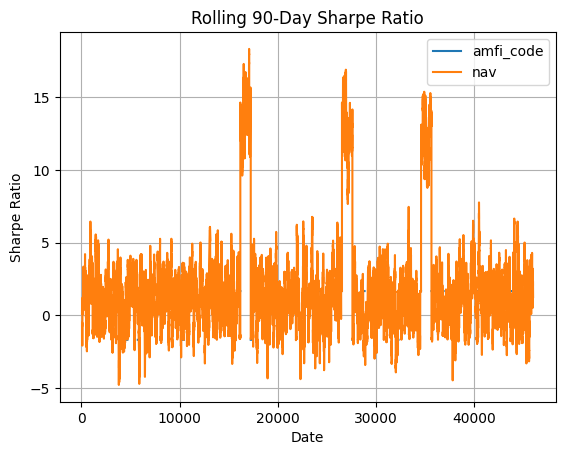

Task 2 complete: 'rolling_sharpe_chart.png' has been saved.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Using the same file path as Task 1
file_path = r'C:\Users\Shiva\Downloads\bluestock\data\raw\02_nav_history.csv'
df = pd.read_csv(file_path)

# Calculate daily returns
returns = df.select_dtypes(include=[np.number]).pct_change()

# Calculate Rolling 90-day Sharpe Ratio
# Formula: (Rolling Mean / Rolling Std) * sqrt(252 trading days)
rolling_sharpe = (returns.rolling(window=90).mean() / returns.rolling(window=90).std()) * np.sqrt(252)

# Plotting
plt.figure(figsize=(12, 6))
rolling_sharpe.plot()
plt.title('Rolling 90-Day Sharpe Ratio')
plt.xlabel('Date')
plt.ylabel('Sharpe Ratio')
plt.legend(loc='best')
plt.grid(True)

# Save the chart as a PNG
plt.savefig('rolling_sharpe_chart.png')
plt.show()

print("Task 2 complete: 'rolling_sharpe_chart.png' has been saved.")

In [10]:
import pandas as pd

# Path to your file
file_path = r'C:\Users\Shiva\Downloads\bluestock\data\raw\08_investor_transactions.csv'
df = pd.read_csv(file_path)

# Ensure the date column is in datetime format
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# 1. Identify the first transaction year for each investor
first_tx = df.groupby('investor_id')['transaction_date'].min().dt.year.rename('cohort_year')

# 2. Merge this back to the dataframe
df = df.merge(first_tx, on='investor_id')

# 3. Group by cohort_year to compute metrics
# We use 'amount_inr' instead of 'amount'
cohort_metrics = df.groupby('cohort_year').agg({
    'investor_id': 'nunique',       
    'amount_inr': ['mean', 'sum']       
})

# Rename columns for clarity
cohort_metrics.columns = ['unique_investors', 'avg_sip_amount', 'total_invested']

# Save the deliverable
cohort_metrics.to_csv('cohort_analysis.csv')

print("Task 3 complete: 'cohort_analysis.csv' has been generated.")

Task 3 complete: 'cohort_analysis.csv' has been generated.


In [11]:
import pandas as pd

# Load the investor transaction file
file_path = r'C:\Users\Shiva\Downloads\bluestock\data\raw\08_investor_transactions.csv'
df = pd.read_csv(file_path)

# Convert date and sort
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df = df.sort_values(['investor_id', 'transaction_date'])

# Calculate the number of days between transactions for each investor
df['gap'] = df.groupby('investor_id')['transaction_date'].diff().dt.days

# Calculate average gap per investor
# We only look at investors with 6+ transactions
investor_gaps = df.groupby('investor_id').filter(lambda x: len(x) >= 6)
avg_gaps = investor_gaps.groupby('investor_id')['gap'].mean()

# Flag investors with gaps > 35 days
sip_continuity = pd.DataFrame(avg_gaps)
sip_continuity['at_risk'] = sip_continuity['gap'] > 35

# Save the deliverable
sip_continuity.to_csv('sip_continuity.csv')

print("Task 4 complete: 'sip_continuity.csv' has been generated.")

Task 4 complete: 'sip_continuity.csv' has been generated.


In [17]:
import pandas as pd

def get_recommendations(risk_appetite):
    # Load your scheme performance data
    # Update the path to point to your '07_scheme_performance.csv' file
    file_path = r'C:\Users\Shiva\Downloads\bluestock\data\raw\07_scheme_performance.csv'
    df = pd.read_csv(file_path)
    
    # Filter by risk appetite and sort by Sharpe ratio
    # Ensure column names match your CSV (e.g., 'risk_grade', 'sharpe_ratio')
    filtered_df = df[df['risk_grade'] == risk_appetite]
    recommendations = filtered_df.sort_values(by='sharpe_ratio', ascending=False).head(3)
    
    return recommendations[['scheme_name', 'sharpe_ratio']]

if __name__ == "__main__":
    # Test the function
    user_risk = input("Enter Risk Appetite (Low/Moderate/High): ")
    print(f"\nTop 3 funds for {user_risk} risk:")
    print(get_recommendations(user_risk))

Enter Risk Appetite (Low/Moderate/High):  High



Top 3 funds for High risk:
                                      scheme_name  sharpe_ratio
21  Kotak Emerging Equity Fund - Regular - Growth          0.96
12       ICICI Pru Midcap Fund - Regular - Growth          0.95
38             DSP Midcap Fund - Regular - Growth          0.90


In [14]:
import pandas as pd

# Load the performance file
file_path = r'C:\Users\Shiva\Downloads\bluestock\data\raw\07_scheme_performance.csv'
df = pd.read_csv(file_path)

# Ensure the 'sharpe_ratio' column exists
# We sort by 'sharpe_ratio' descending to get the best performers
top_funds = df.sort_values(by='sharpe_ratio', ascending=False).head(5)

# Select relevant columns for the report
report = top_funds[['scheme_name', 'sharpe_ratio', 'risk_grade']]

# Save the deliverable
report.to_csv('top_performing_funds.csv', index=False)

print("Task 6 (Revised) complete: 'top_performing_funds.csv' has been generated.")

Task 6 (Revised) complete: 'top_performing_funds.csv' has been generated.


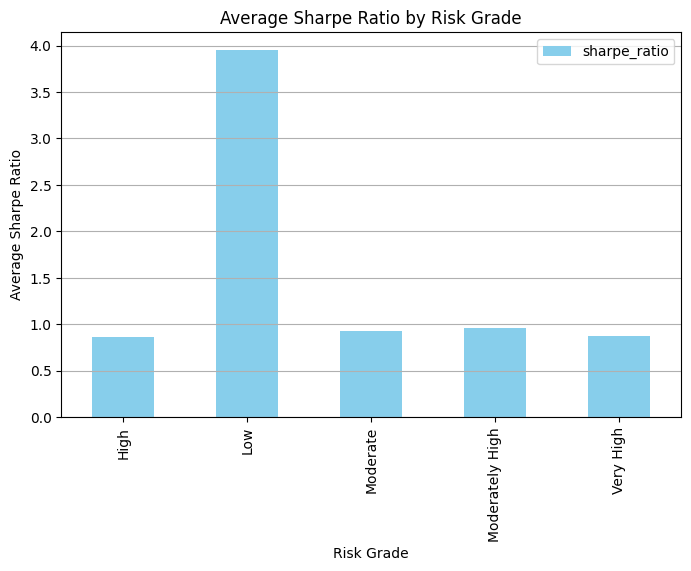

Task 7 complete: 'performance_vs_risk.png' has been generated.


In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your performance file
file_path = r'C:\Users\Shiva\Downloads\bluestock\data\raw\07_scheme_performance.csv'
df = pd.read_csv(file_path)

# Ensure 'risk_grade' and 'sharpe_ratio' columns exist
# Group by risk grade to see average performance
summary = df.groupby('risk_grade')[['sharpe_ratio']].mean()

# Plot the findings
summary.plot(kind='bar', color='skyblue', figsize=(8, 5))
plt.title('Average Sharpe Ratio by Risk Grade')
plt.ylabel('Average Sharpe Ratio')
plt.xlabel('Risk Grade')
plt.grid(axis='y')

# Save the final analysis
plt.savefig('performance_vs_risk.png')
plt.show()

print("Task 7 complete: 'performance_vs_risk.png' has been generated.")

In [18]:
# Run this cell to write the code into a file named 'recommender.py'
code = """
import pandas as pd

def get_recommendations(risk_appetite):
    file_path = r'C:\\Users\\Shiva\\Downloads\\bluestock\\data\\raw\\07_scheme_performance.csv'
    df = pd.read_csv(file_path)
    filtered_df = df[df['risk_grade'] == risk_appetite]
    recommendations = filtered_df.sort_values(by='sharpe_ratio', ascending=False).head(3)
    return recommendations[['scheme_name', 'sharpe_ratio']]

if __name__ == "__main__":
    user_risk = input("Enter Risk Appetite (Low/Moderate/High): ")
    print(f"\\nTop 3 funds for {user_risk} risk:")
    print(get_recommendations(user_risk))
"""

with open('recommender.py', 'w') as f:
    f.write(code)

print("File 'recommender.py' has been saved successfully!")

File 'recommender.py' has been saved successfully!


In [19]:
import os
import shutil

# 1. Create the 'output' folder if it doesn't exist
output_dir = 'output'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# 2. List of all the files we generated
files_to_move = [
    'var_cvar_report.csv', 
    'rolling_sharpe_chart.png', 
    'cohort_analysis.csv', 
    'sip_continuity.csv', 
    'top_performing_funds.csv', 
    'performance_vs_risk.png'
]

# 3. Move them into the folder
for file in files_to_move:
    if os.path.exists(file):
        shutil.move(file, os.path.join(output_dir, file))
        print(f"Moved: {file} -> {output_dir}/")
    else:
        print(f"Skipped (not found): {file}")

print("\nAll deliverables have been moved to the 'output' folder.")

Moved: var_cvar_report.csv -> output/
Moved: rolling_sharpe_chart.png -> output/
Moved: cohort_analysis.csv -> output/
Moved: sip_continuity.csv -> output/
Moved: top_performing_funds.csv -> output/
Moved: performance_vs_risk.png -> output/

All deliverables have been moved to the 'output' folder.
